<a href="https://colab.research.google.com/github/Hruthikaveldi/adm_project/blob/main/18_4(NEW).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("Mobiles_Dataset_2025.csv", encoding="ISO-8859-1")

# Clean numeric columns
def clean_column(col):
    return pd.to_numeric(df[col].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

df['RAM'] = clean_column('RAM')
df['Front Camera'] = clean_column('Front Camera')
df['Back Camera'] = clean_column('Back Camera')
df['Battery Capacity'] = clean_column('Battery Capacity')
df['Screen Size'] = clean_column('Screen Size')

# Clean price columns
price_columns = [
    'Launched Price (Pakistan)', 'Launched Price (India)',
    'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)'
]

for col in price_columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Drop missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Remove outliers using IQR
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    return dataframe[(dataframe[column] >= Q1 - 1.5*IQR) & (dataframe[column] <= Q3 + 1.5*IQR)]

for col in ['RAM', 'Front Camera', 'Back Camera', 'Battery Capacity', 'Screen Size']:
    df = remove_outliers_iqr(df, col)

# Normalize
scaler = MinMaxScaler()
scaled_features = ['RAM', 'Front Camera', 'Back Camera', 'Battery Capacity', 'Screen Size']
df[scaled_features] = scaler.fit_transform(df[scaled_features])

# View cleaned data
print(df.head())


   Company Name               Model Name Mobile Weight       RAM  \
3         Apple     iPhone 16 Plus 128GB          203g  0.428571   
4         Apple     iPhone 16 Plus 256GB          203g  0.428571   
5         Apple     iPhone 16 Plus 512GB          203g  0.428571   
9         Apple  iPhone 16 Pro Max 128GB          221g  0.428571   
10        Apple  iPhone 16 Pro Max 256GB          221g  0.714286   

    Front Camera  Back Camera   Processor  Battery Capacity  Screen Size  \
3           0.35     0.434783  A17 Bionic          0.000156     0.561798   
4           0.35     0.434783  A17 Bionic          0.000156     0.561798   
5           0.35     0.434783  A17 Bionic          0.000156     0.561798   
9           0.35     0.434783     A17 Pro          0.000156     0.561798   
10          0.35     0.434783     A17 Pro          0.000156     0.561798   

    Launched Price (Pakistan)  Launched Price (India)  Launched Price (China)  \
3                    249999.0                   89999

In [2]:
pip install matplotlib seaborn


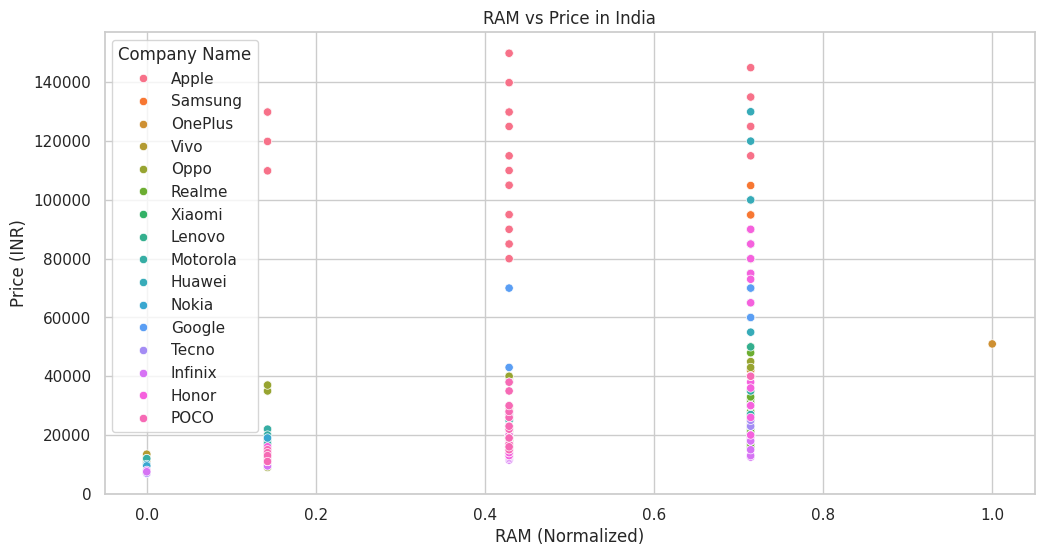

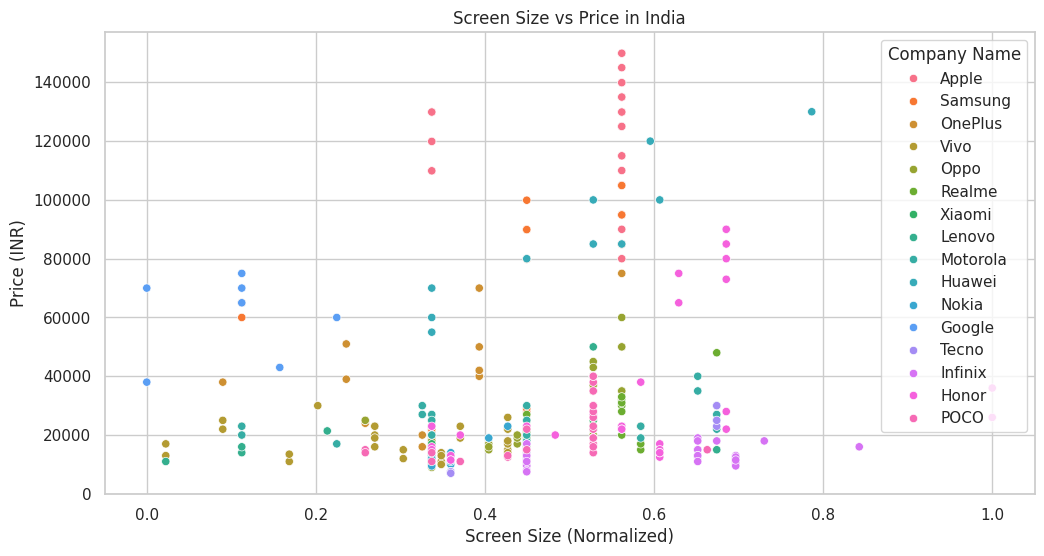

<ipython-input-3-071d8338e0f5>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, palette="coolwarm")


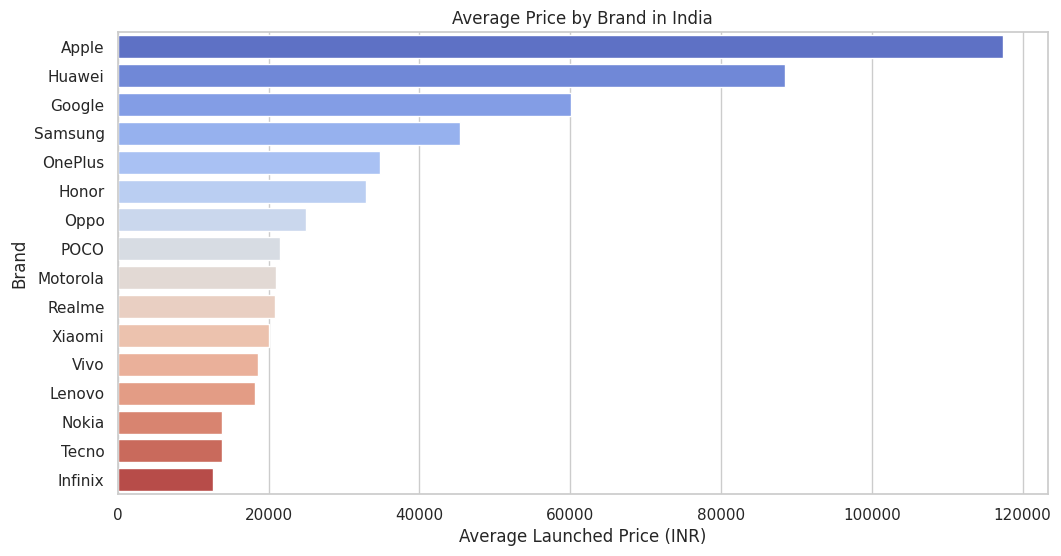

<ipython-input-3-071d8338e0f5>:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Launched Year', y='Battery Capacity', marker='o', ci=None)


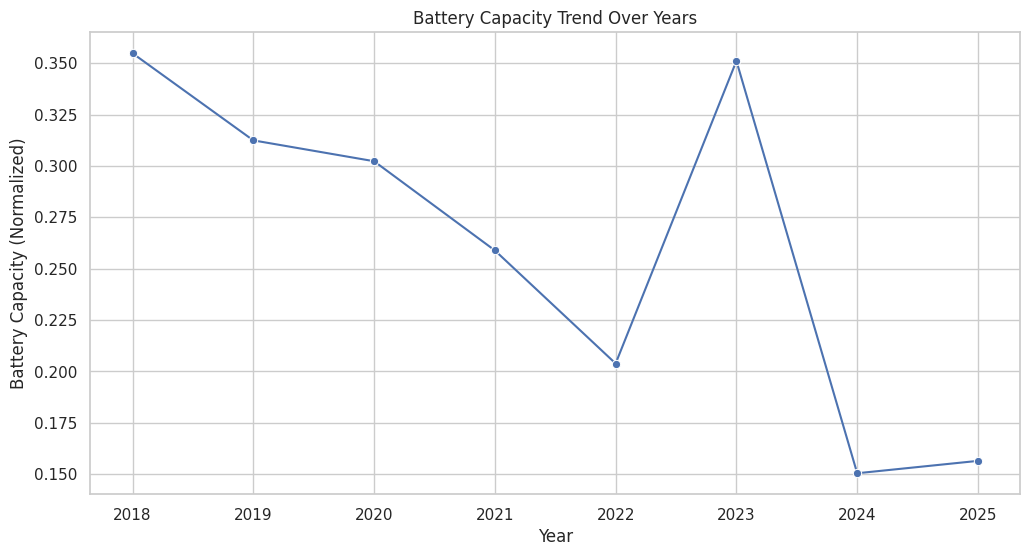

<ipython-input-3-071d8338e0f5>:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Launched Year', y='Front Camera', marker='o', ci=None)


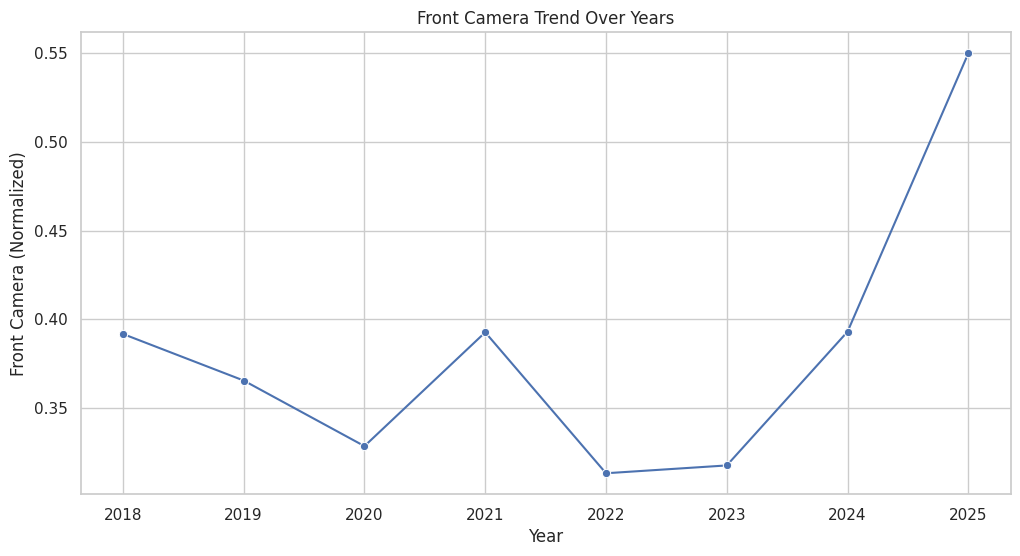

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the theme
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. RAM vs Price
sns.scatterplot(data=df, x='RAM', y='Launched Price (India)', hue='Company Name')
plt.title("RAM vs Price in India")
plt.xlabel("RAM (Normalized)")
plt.ylabel("Price (INR)")
plt.show()

# 2. Screen Size vs Price
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Screen Size', y='Launched Price (India)', hue='Company Name')
plt.title("Screen Size vs Price in India")
plt.xlabel("Screen Size (Normalized)")
plt.ylabel("Price (INR)")
plt.show()

# 3. Most Expensive Brand (Average Price)
plt.figure(figsize=(12, 6))
avg_price = df.groupby("Company Name")['Launched Price (India)'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index, palette="coolwarm")
plt.title("Average Price by Brand in India")
plt.xlabel("Average Launched Price (INR)")
plt.ylabel("Brand")
plt.show()

# 4. Trend of Battery Capacity over the Years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Launched Year', y='Battery Capacity', marker='o', ci=None)
plt.title("Battery Capacity Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Battery Capacity (Normalized)")
plt.show()

# 5. Front Camera Demand Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Launched Year', y='Front Camera', marker='o', ci=None)
plt.title("Front Camera Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Front Camera (Normalized)")
plt.show()


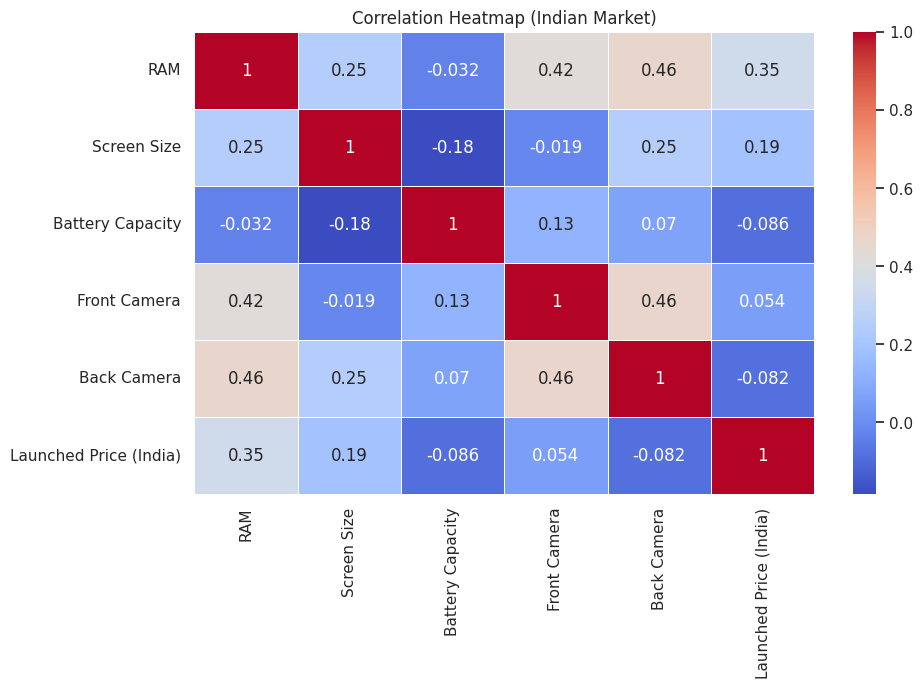

In [4]:
# Correlation heatmap (India-focused numerical features only)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
india_corr = df[['RAM', 'Screen Size', 'Battery Capacity', 'Front Camera', 'Back Camera', 'Launched Price (India)']].corr()
sns.heatmap(india_corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Indian Market)")
plt.show()


In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection: Keep only relevant features for modeling
features = ['RAM', 'Screen Size', 'Battery Capacity', 'Front Camera', 'Back Camera', 'Company Name']
target = 'Launched Price (India)'

# 2. Encode Categorical Variables (Company Name)
le = LabelEncoder()
df['Company_Encoded'] = le.fit_transform(df['Company Name'])

# Final feature set
X = df[['RAM', 'Screen Size', 'Battery Capacity', 'Front Camera', 'Back Camera', 'Company_Encoded']]
y = df['Launched Price (India)']

# Display prepared data
print("Encoded Company Labels:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nSample Features:\n", X.head())
print("\nTarget (Price):\n", y.head())


Encoded Company Labels: {'Apple': np.int64(0), 'Google': np.int64(1), 'Honor': np.int64(2), 'Huawei': np.int64(3), 'Infinix': np.int64(4), 'Lenovo': np.int64(5), 'Motorola': np.int64(6), 'Nokia': np.int64(7), 'OnePlus': np.int64(8), 'Oppo': np.int64(9), 'POCO': np.int64(10), 'Realme': np.int64(11), 'Samsung': np.int64(12), 'Tecno': np.int64(13), 'Vivo': np.int64(14), 'Xiaomi': np.int64(15)}

Sample Features:
          RAM  Screen Size  Battery Capacity  Front Camera  Back Camera  \
3   0.428571     0.561798          0.000156          0.35     0.434783   
4   0.428571     0.561798          0.000156          0.35     0.434783   
5   0.428571     0.561798          0.000156          0.35     0.434783   
9   0.428571     0.561798          0.000156          0.35     0.434783   
10  0.714286     0.561798          0.000156          0.35     0.434783   

    Company_Encoded  
3                 0  
4                 0  
5                 0  
9                 0  
10                0  

Target (P

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict
y_pred = regressor.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.42658411802044616
MAE: 18897.60631233568
MSE: 656411312.3788092


In [7]:
# Categorize into Budget (0), Mid (1), Premium (2)
def label_price(price):
    if price < 10000:
        return 0  # Budget
    elif price < 25000:
        return 1  # Mid-Range
    else:
        return 2  # Premium

df['Price_Category'] = df['Launched Price (India)'].apply(label_price)
y_class = df['Price_Category']

# Train classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_class = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred_class))
print(classification_report(y_test, y_pred_class))


[[ 2  2  0]
 [ 0 42  1]
 [ 0  6 20]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.84      0.98      0.90        43
           2       0.95      0.77      0.85        26

    accuracy                           0.88        73
   macro avg       0.93      0.75      0.81        73
weighted avg       0.89      0.88      0.87        73



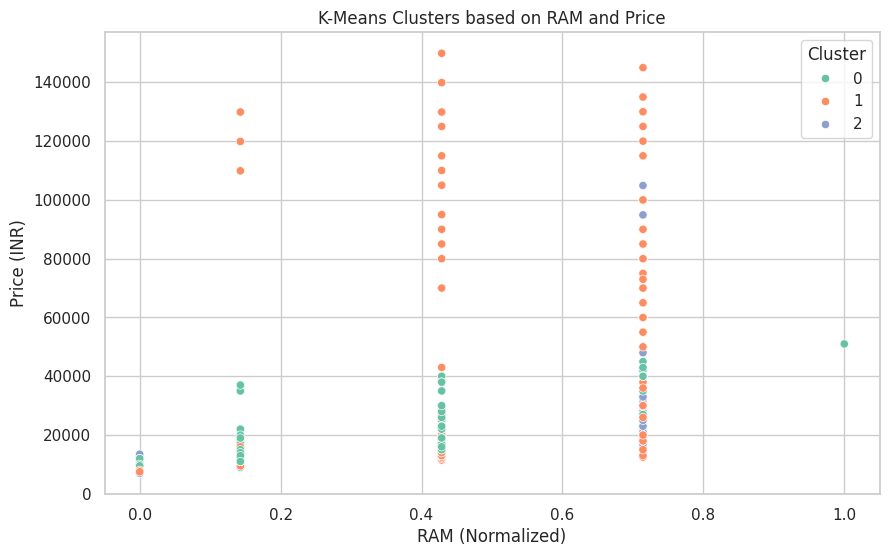

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Add to DataFrame
df['Cluster'] = cluster_labels

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RAM', y='Launched Price (India)', hue='Cluster', palette='Set2')

plt.title("K-Means Clusters based on RAM and Price")
plt.xlabel("RAM (Normalized)")
plt.ylabel("Price (INR)")
plt.show()


In [10]:
!pip install gradio --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.0 MB/s eta 0:00:00


In [11]:
import gradio as gr
import numpy as np

# 🔮 Use trained model (regressor) and LabelEncoder (le)
def predict_price(ram, screen, battery, front_cam, back_cam, company_name):
    encoded_company = le.transform([company_name])[0]
    features = np.array([[ram, screen, battery, front_cam, back_cam, encoded_company]])
    price = regressor.predict(features)[0]
    return f"💰 Estimated Price in India: ₹{int(price):,}"


In [ ]:
# 🏷️ Dropdown choices from dataset
company_list = sorted(df['Company Name'].unique().tolist())

iface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Slider(1, 16, step=1, label="RAM (GB)"),
        gr.Slider(4.0, 7.5, step=0.1, label="Screen Size (inches)"),
        gr.Slider(1000, 7000, step=100, label="Battery (mAh)"),
        gr.Slider(0, 64, step=1, label="Front Camera (MP)"),
        gr.Slider(5, 200, step=1, label="Back Camera (MP)"),
        gr.Dropdown(choices=company_list, label="Company Name")
    ],
    outputs="text",
    title="📱 Mobile Price Predictor (India)",
    description="Enter mobile specs to get estimated launch price in ₹INR."
)

iface.launch(debug=True)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b42f9727c98a3e8046.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Created dataset file at: .gradio/flagged/dataset1.csv
